In [1]:
from importlib import reload
import mesa
from mesa.discrete_space import FixedAgent, OrthogonalMooreGrid
import pandas as pd
import numpy as np
from scipy.stats import bernoulli
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t # For t-distribution

In [ ]:

# To represent uncertainty attitudes, draw values that are more extreme (e.g., drawing from a norm dist with more kurtosis)
# Could find distribution of risk and ambiguity attitudes that were found empirically.

import numpy as np
import pandas as pd

# Utility function of engaging in rule-breaking behavior
def utility_function(starting_wealth, gamma):
    """
    Calculate the utility of engaging in rule-breaking behavior.
    Parameters:
    starting_wealth (float): The amount of money.
    gamma (float): The risk aversion parameter.
    Returns:
    float: The utility of engaging in rule-breaking behavior.
    """
# keep gamma in exponent (instead of gamma - 1)
# Keep restriction that gamma must be greater than 0
    
    if gamma <= 0:
        raise ValueError("gamma must be positive")
    
    return np.longdouble(np.sign(starting_wealth) * (np.abs(starting_wealth))**(gamma)) 

# Prelec's probability weighting function

def prelec(beta, alpha, p):
    """
    Prelec's probability weighting function.
    Parameters:
    beta (float): Uncertainty aversion parameter.
    alpha (float): Likelihood uncertainty parameter.
    p (float): Probability of not being caught engaging in rule-breaking behavior.
    Returns:
    float: Weighted probability.
    """
    if p == 0:
        return 0
    try:
        log_val = -beta * (-np.log(p)) ** alpha
    except RuntimeWarning:
        log_val = float('-inf')
    
    # Clamping extremely large or small values
    if log_val > 700:  # np.log(np.finfo(np.float64).max)
        log_val = 700
    elif log_val < -700:  # np.log(np.finfo(np.float64).tiny)
        log_val = -700
    
    return np.longdouble(np.exp(log_val))

# Decision-making functions for rule-breaking behavior

def SV_rule_break(reward_rb, cost_rb, starting_wealth, p, gamma, beta, alpha):
    """
    Decision-making function to determine whether to engage in rule-breaking behavior.
    
    Parameters:
    reward_rb (float): Instant benefit from rule-breaking behavior.
    cost_rb (float): Cost of engaging in rule-breaking behavior.
    starting_wealth (float): Initial wealth of the individual.
    p (float): Probability of not being caught engaging in rule-breaking behavior.
    gamma (float): Risk aversion parameter.
    beta (float): Likelihood sensitivity parameter for Prelec's probability weighting function.
    alpha (float): Optimism/pessimism parameter for Prelec's probability weighting function.
    
    Returns:
    str: Decision outcome.
    """
    
    # Calculate expected utility of engaging in rule-breaking behavior
    # w(p)u(θ+A)-(1-w(p))u(θ-c)
    # SV_rule_breaking = ( (prelec(p, beta, alpha)) * (utility_function(reward_rb + starting_wealth, gamma) )  ) - ( (1-prelec(p, beta, alpha)) * utility_function(starting_wealth - cost_rb, gamma) )
    
    # w(p)u(θ+A)-(1-w(p))u(θ-c)
    SV_rule_breaking = (prelec(p=p, beta=beta, alpha=alpha) * utility_function(starting_wealth=reward_rb + starting_wealth, gamma=gamma)) + np.negative(- \
                        ((1 - prelec(p=p, beta=beta, alpha=alpha)) * utility_function(starting_wealth=starting_wealth - cost_rb, gamma=gamma)) )


    return SV_rule_breaking

# Decision-making function for following rules
def SV_follow_rules(reward_rf, starting_wealth, gamma):
    """
    Decision-making function to determine whether to engage in rule-breaking behavior.
    
    Parameters:
    reward_rf (float): Instant benefit of following the rules.
    starting_wealth (float): Initial wealth of the individual.
    p (float): Probability of not being caught engaging in rule-breaking behavior.
    gamma (float): Risk aversion parameter.
    
    Returns:
    float: Expected utility.
    """
    
    # Calculate expected utility of not engaging in rule-breaking behavior
    total_wealth = reward_rf + starting_wealth
    SV_following_rules = utility_function(total_wealth, gamma=gamma)
    
    return SV_following_rules

# Function to calculate income rank
def cal_income_rank(i,n):
    """
    Calculate the income rank of individual i in a reference group of size n.
    """
    return (i - 1) / (n - 1)

def desperation_utility_function(lambd, gamma, starting_wealth):
    """
    Calculate the utility of engaging in rule-breaking behavior based on relative deprivation.
    
    Parameters:
    income_rank (float): The income rank of the individual in the reference group.
    lambd (float): The relative deprivation parameter.
    starting_wealth (float): The initial wealth of the individual.
    
    Returns:
    float: Adjusted utility function value.
    """
    
    return (np.longdouble(np.sign(starting_wealth) * (np.abs(starting_wealth))**(gamma))) + lambd*(np.abs(starting_wealth))

def SV_relative_desp_RB(gamma, lambd, starting_wealth, p, beta, alpha, reward_rb, cost_rb):
    """
    Adjust the utility function based on relative deprivation.
    
    Parameters:
    income_rank (float): The income rank of the individual in the reference group.
    gamma (float): The risk aversion parameter.
    
    Returns:
    float: Adjusted utility function value.
    """

    # Adjust gamma based on relative deprivation
    SV = (prelec(p=p, beta=beta, alpha=alpha) * desperation_utility_function(starting_wealth=reward_rb + starting_wealth, gamma=gamma, lambd=lambd)) + np.negative(- \
                        ((1 - prelec(p=p, beta=beta, alpha=alpha)) * desperation_utility_function(starting_wealth=starting_wealth - cost_rb, gamma=gamma, lambd=lambd))  )
    
    return SV

# Softmax function
def softmax(SV_rule_breaking, SV_following_rules):
    """Compute the softmax of vector SVs."""
    SVs = np.array([SV_rule_breaking, SV_following_rules])  # Ensure SVs is a numpy array

    # Check for NaN or inf values
    if np.isnan(SVs).any():
        raise ValueError("Input contains NaN values.")
    if np.isinf(SVs).any():
        raise ValueError("Input contains infinity values.")

    stable_SVs = SVs - SVs.max(axis=0)  # Subtract the max value for numerical stability, preventing overflow in exp
    e_SVs = np.exp(stable_SVs)  # Exponentiate the SVs

    sum_exp_SVs = e_SVs.sum(axis=0)
    # Prevent division by zero
    if sum_exp_SVs == 0:
        return np.zeros_like(SVs)
    
    return e_SVs / sum_exp_SVs

def bounded_softmax(SV_rb, SV_rf, tau=3, theta=1.5):
    """
    Probabilistic bounded-rational choice rule.
    
    Parameters
    ----------
    SV_rb : float
        Subjective value of rule-breaking.
    SV_rf : float
        Subjective value of rule-following.
    tau : float
        Satisficing threshold — the minimum margin needed for rule-breaking
        to feel 'worth it'. Larger tau = stronger inertia toward rule-following.
    theta : float
        Noise / bounded-rationality parameter.
        Larger theta = more random, less sensitive to value differences.
        
    Returns
    -------
    list of float
        [P(rule-break), P(rule-follow)]
    """
    delta = (SV_rb - SV_rf - tau) / theta
    p_rb = 1 / (1 + np.exp(-delta))  # logistic transform
    return [p_rb, 1 - p_rb]



## Agent

In [ ]:
class individual(FixedAgent):
    """An agent that chooses between two options based on the subjective value."""
    def __init__(self, model, lambd, gamma, reward_rb, reward_rf, cost_rb, min_start_wealth, p, beta_loc, beta_scale, 
                 alpha_loc, alpha_scale, num_neighbors, income_rank_threshold):
        """ Create a new decision maker agent.
        Args:
            self: Object that stores characteristics of the agent.
            model: Reference to the model this agent belongs to.
            num_neighbors: Number of neighbors to consider for relative desperation.
            gamma: Utility parameter.
            reward_rb: Reward for rule breaking.
            reward_rf: Reward for following rules.
            cost_rb: Cost of rule breaking.
            min_start_wealth: The  minimum starting wealth of the agent.
            p: Probability of NOT being caught for rule-breaking.
            beta_loc: Mean optimism/pessimism (aversion) of the distribution.
            beta_scale: Scale of the distribution for beta.
            alpha_loc: Mean likelihood sensitivity of the distribution.
            alpha_scale: Scale of the distribution for alpha.
            lambd: Desperation severity parameter.
            alpha: Likelihood sensitivity.
            desperate_state: State of relative desperation (0 = not desperate, 1 = desperate).
            income_rank_threshold: Threshold for relative desperation based on income rank.
            radius: Radius for neighborhood search.
        """
        super().__init__(model)
        self.lambd = lambd
        self.gamma = gamma
        self.reward_rb = reward_rb
        self.reward_rf = reward_rf
        self.cost_rb = cost_rb
        self.p = p
        self.beta = (t.rvs(df=(model.width*model.height)-1, loc=beta_loc, scale=beta_scale, size=1)).item()
        self.alpha = (t.rvs(df=(model.width*model.height)-1, loc=alpha_loc, scale=alpha_scale, size=1)).item()

        self.wealth = (np.random.pareto(a=3, size=1) * 200 + min_start_wealth).item() # Initial wealth drawn from a Pareto distribution
        self.income_rank_threshold = income_rank_threshold
        self.num_neighbors = num_neighbors
        self.desperate_state = 0  # Initialize desperate state to 0 (not desperate)
        self.decision = 0  # Initialize decision to 0 (follow rules)
        self.caught = False  # Initialize caught state to False
        self.income_rank = 0  # Initialize income rank to 0
        self.rb_choice = 0  # Initialize rule-breaking choice to 0 (follow rules)

    def relative_desperation(self):
        """Determine the relative desperation of the agent based on income rank."""
        # Get neighbors within the specified radius
        neighbors = self.model.grid.get_neighbors(self.pos, moore=True, include_center=False, radius=self.num_neighbors)

        # Get a vector of the wealth of the agents in the neighborhood
        neighbor_wealths = [neighbor.wealth for neighbor in neighbors] 
        # Count the number of neighbors with wealth lower than the agent's wealth
        num_poorer_neighbors = sum(1 for w in neighbor_wealths if w <= self.wealth)

        # Calculate the income rank of the agent in its neighborhood
        income_rank = cal_income_rank(i=num_poorer_neighbors, n=len(neighbors))
        self.income_rank = income_rank  # Store the income rank in the agent's attributes

        # Label the agent as desperate if their income rank is less than 0
        if income_rank < self.income_rank_threshold:  # Threshold for relative desperation
            self.desperate_state = 1  # Agent is relatively desperate
        else:
            self.desperate_state = 0  # Agent is not relatively desperate


    def compute_expected_utilities(self):
        """Choose an option based on subjective value. If agent is relatively desperate, use a different utility function."""
        if self.desperate_state == 1:
            # If the agent is relatively desperate, use a different utility function
            self.SV_rule_break = SV_relative_desp_RB(
            gamma=self.gamma, starting_wealth=self.wealth, lambd=self.lambd, p=self.p, beta=self.beta, alpha=self.alpha, reward_rb=self.reward_rb, cost_rb=self.cost_rb)
        else:
            self.SV_rule_break = SV_rule_break(gamma=self.gamma, reward_rb=self.reward_rb, cost_rb=self.cost_rb, p=self.p, beta=self.beta, alpha=self.alpha, starting_wealth=self.wealth)  # SV of rule breaking
        self.SV_follow_rules = SV_follow_rules(reward_rf=self.reward_rf, starting_wealth=self.wealth, gamma=self.gamma) # SV of following rules

        # --- Bounded Softmax Decision Rule ---
        # tau = satisficing threshold, theta = noise level
        tau = 1.0  # you can tune this to control conservatism
        theta = 1.0  # higher = noisier / less rational

        probs = bounded_softmax(self.SV_rule_break, self.SV_follow_rules, tau=tau, theta=theta)
        rb_choice = bernoulli.rvs(probs[0])

        self.decision = int(rb_choice)  # 1 = breaks rules, 0 = follows
        return rb_choice
    
    def decision_cycle(self):
        self.wealth_start = self.wealth
        self.relative_desperation() # Determine if the agent is relatively desperate
        self.compute_expected_utilities()
    
    def step(self):
        self.decision_cycle()

        # Log the first value
        self.model.datacollector.add_table_row(
            "table",
            {"step": self.model.steps, "agent_id": self.unique_id, "decision": self.decision, "wealth": self.wealth}
        )
        self.decision_cycle()

        # Log the second value
        self.model.datacollector.add_table_row(
            "table",
            {"step": self.model.steps, "agent_id": self.unique_id, "decision": self.decision, "wealth": self.wealth}
        )

        # Log the third value
        self.model.datacollector.add_table_row(
            "table",
            {"step": self.model.steps, "agent_id": self.unique_id, "decision": self.decision, "wealth": self.wealth}
        )

        # Log the fourth value
        self.model.datacollector.add_table_row(
            "table",
            {"step": self.model.steps, "agent_id": self.unique_id, "decision": self.decision, "wealth": self.wealth}
        )

        # Log the fifth value
        self.model.datacollector.add_table_row(
            "table",
            {"step": self.model.steps, "agent_id": self.unique_id, "decision": self.decision, "wealth": self.wealth}
        )
   
        # Update wealth based on decision
        if self.decision == 1: # breaks rules
            # If the agent chooses to break the rules and is NOT caught
            if bernoulli.rvs(self.p) == 1:
                self.caught = False
                self.wealth += self.reward_rb
            # If the agent chooses to break the rules and is caught
            else:
                self.caught = True
                self.wealth -= self.cost_rb
        else: 
            # If the agent chooses to follow the rules
            self.wealth += self.reward_rf
        # Deduct the cost of living (e.g., paying for food, rent, etc.)
        living_cost_rate = np.clip(np.random.normal(0.6, 0.1), 0.1, 1)
        self.wealth = self.wealth - (living_cost_rate * self.reward_rf)

        # Update the agent's wealth based on the choice made
        self.wealth_end = self.wealth


## Model

In [142]:
from mesa import Model
from mesa.datacollection import DataCollector
from mesa.space import SingleGrid
import numpy as np

# from .agents import decision_maker

class rel_DMAP_model(Model):
    """A model with a number of decision makers."""
    def __init__(self, width, height, lambd, gamma, reward_rb, reward_rf, cost_rb, min_start_wealth, p, 
                 beta_loc, beta_scale, alpha_loc, alpha_scale, num_neighbors, income_rank_threshold):
        super().__init__()
        self.width = width
        self.height = height
        self.grid = SingleGrid(width, height, torus=True)

        self.lambd = lambd
        self.gamma = gamma
        self.reward_rb = reward_rb
        self.reward_rf = reward_rf
        self.cost_rb = cost_rb
        self.p = p

        self.desperate_state = 0  # Initialize desperate state to 0 (not desperate)
        self.decision = 0  # Initialize decision to 0 (follow rules)
        self.caught = False  # Initialize caught state to False
        self.income_rank = 0  # Initialize income rank to 0
        self.rb_choice = 0  # Initialize rule-breaking choice to 0 (follow rules)

        # Create agents and place them on the grid
        for _, pos in self.grid.coord_iter():
            # Create a new agent at the current position
            agent = individual(
                model=self, lambd=self.lambd, gamma=self.gamma, reward_rb=self.reward_rb,
                reward_rf=self.reward_rf, cost_rb=self.cost_rb, min_start_wealth=min_start_wealth,
                p=self.p, beta_loc=beta_loc, beta_scale=beta_scale, alpha_loc=alpha_loc, 
                alpha_scale=alpha_scale, num_neighbors=num_neighbors, income_rank_threshold=income_rank_threshold)
            # Add the agent to the grid at the current position
            self.grid.place_agent(agent, pos)

    
        self.datacollector = mesa.DataCollector(
            model_reporters={"Proportion crime": crime_proportion},
            agent_reporters={ "Wealth Start": lambda a: getattr(a, "wealth_start", a.wealth), "Wealth End": 
                             lambda a: getattr(a, "wealth_end", a.wealth), "income rank":"income_rank", 
                             "desperate_state": "desperate_state", "uncert_aver": "beta", "uncert_insensitive": "alpha",
                             "Rule-breaking choice": "decision", "Caught": "caught", "SV_rule_break": "SV_rule_break", 
                             "SV_follow_rules": "SV_follow_rules"},
                             tables = {"table": ["step", "agent_id", "decision", "wealth" ]  }
            )
        self.running = True
        self.datacollector.collect(self)
    
    def step(self):
        self.agents.do("step")
        self.datacollector.collect(self)
        

    

        


## Additional functions

In [143]:
def crime_proportion(model):
    agent_crimes = [agent.decision for agent in model.agents]
    n = model.width * model.height  # Total number of agents in the grid
    proportion = (sum(agent_crimes) ) / n
    return proportion

def gini_coefficient(model):
    """Calculate the Gini coefficient for the wealth distribution of agents in the model."""
    agent_wealths = [agent.wealth for agent in model.agents]
    n = len(agent_wealths)
    if n == 0:
        return 0  # Avoid division by zero if there are no agents
    sorted_wealths = np.sort(agent_wealths)
    cumulative_wealth = np.cumsum(sorted_wealths)
    total_wealth = cumulative_wealth[-1]
    
    # Gini coefficient formula
    gini = (n + 1 - 2 * np.sum(cumulative_wealth) / total_wealth) / n
    return gini

## Run Model

In [ ]:
# Run the model for a number of steps
test_model = rel_DMAP_model(lambd=0.1, gamma=0.3, reward_rb=50, reward_rf=30, cost_rb=250, 
                            beta_loc=1, beta_scale=0.5, alpha_loc=1, alpha_scale=0.5, 
                            min_start_wealth=100, p=0.8, width=40, height=40, num_neighbors=20, income_rank_threshold=0)
for _ in range(500):
    test_model.step()

model_df = test_model.datacollector.get_model_vars_dataframe()
agent_df = test_model.datacollector.get_agent_vars_dataframe()
table_df = test_model.datacollector.get_table_dataframe("table")
table_df = table_df.reset_index()

# Save as CSV files
model_df.to_csv("model_data.csv")
agent_df.to_csv("agent_data.csv")
table_df.to_csv("table_data.csv")


In [ ]:
# Plot each agent's wealth over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=table_df, x="step", y="wealth", hue="agent_id")
plt.title("Wealth Over Time by Agent")

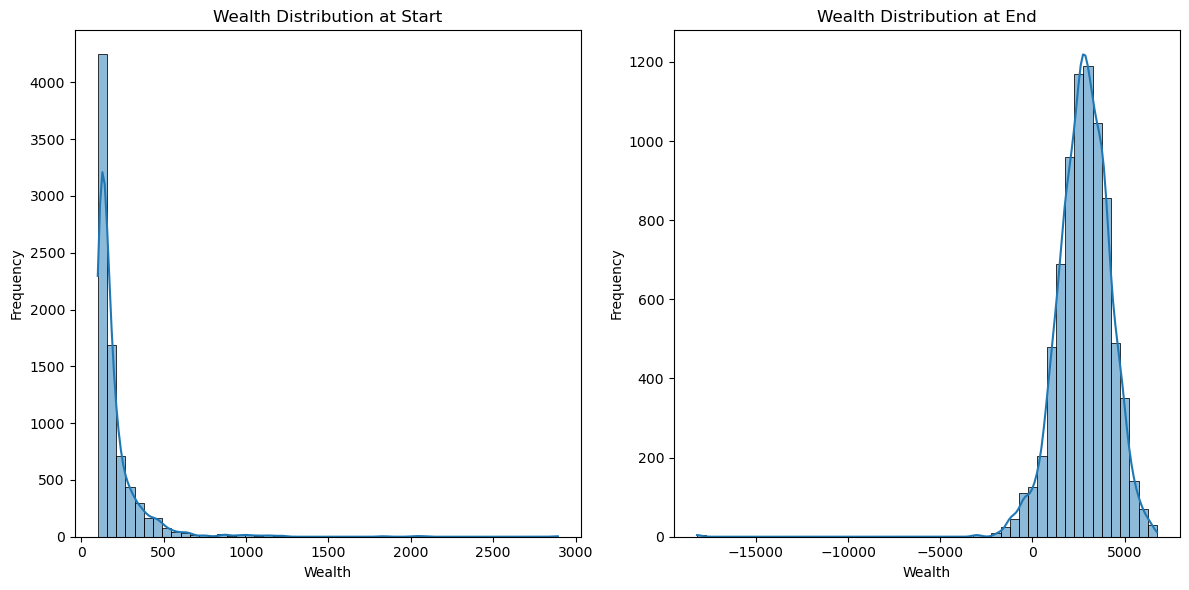

In [145]:
# Plot the wealth distribution at the start and end of the simulation
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(table_df[table_df['step'] == 1]['wealth'], bins=50, kde=True)
plt.title("Wealth Distribution at Start")
plt.xlabel("Wealth")
plt.ylabel("Frequency")
plt.subplot(1, 2, 2)
sns.histplot(table_df[table_df['step'] == table_df['step'].max()]['wealth'], bins=50, kde=True)
plt.title("Wealth Distribution at End")
plt.xlabel("Wealth")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

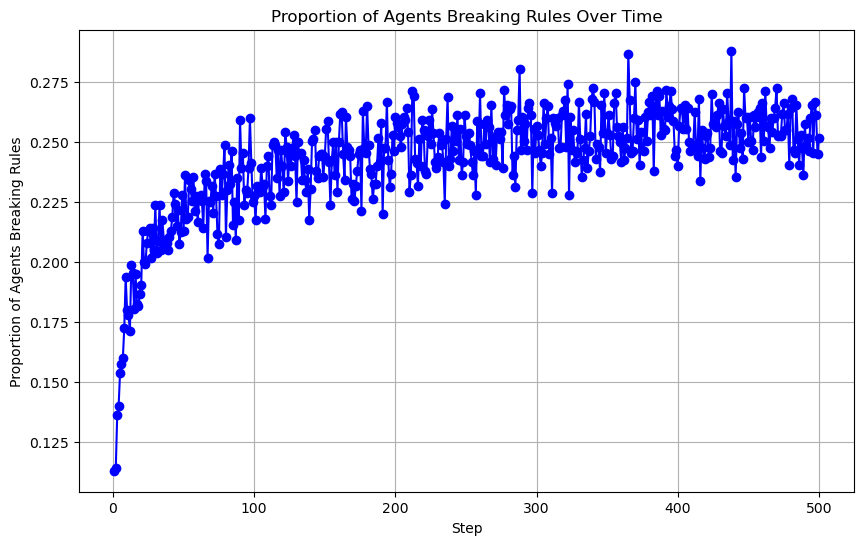

In [146]:
# Make the index its own column
model_df = model_df.reset_index()
# Look at the proportion of agents who break the rules over time
proportion_crime = model_df
# remove the first row (time step 0)
proportion_crime = proportion_crime[proportion_crime['index'] > 0]
proportion_crime = proportion_crime.rename(columns={"Step": "index"})
# Plot the proportion of agents who break the rules over time
plt.figure(figsize=(10, 6))
plt.plot(proportion_crime["index"], proportion_crime["Proportion crime"], marker='o', linestyle='-', color='b')
plt.title("Proportion of Agents Breaking Rules Over Time")
plt.xlabel("Step")
plt.ylabel("Proportion of Agents Breaking Rules")
plt.grid()
plt.show()


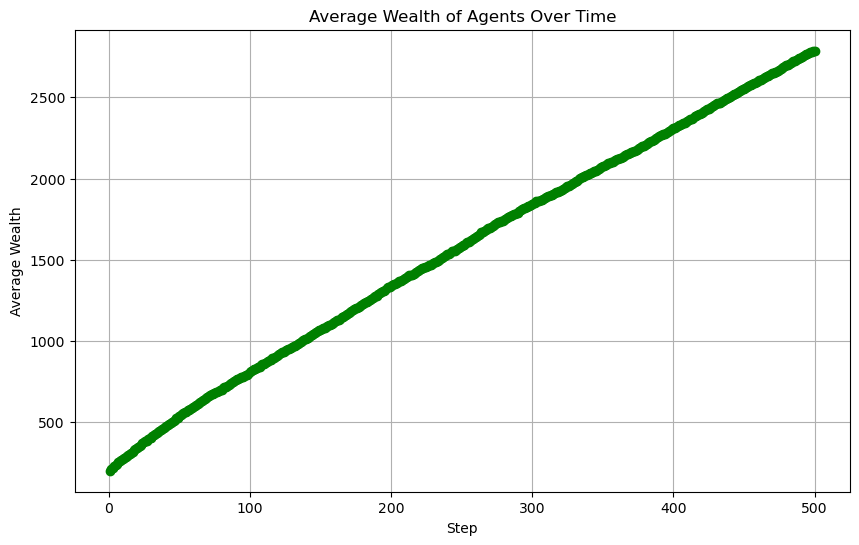

In [147]:
# Plotting agent's average wealth over time
avg_wealth_over_time = table_df.groupby('step')['wealth'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(avg_wealth_over_time['step'], avg_wealth_over_time['wealth'], marker='o', linestyle='-', color='g')
plt.title("Average Wealth of Agents Over Time")
plt.xlabel("Step")
plt.ylabel("Average Wealth")
plt.grid()
plt.show()

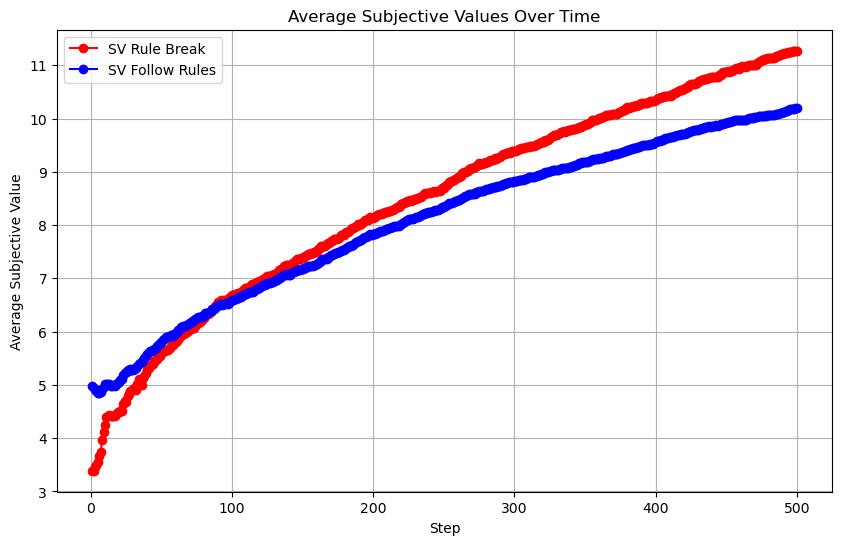

In [148]:
# Plotting average subjective values over time
avg_SV_over_time = agent_df.groupby('Step')[['SV_rule_break', 'SV_follow_rules']].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(avg_SV_over_time['Step'], avg_SV_over_time['SV_rule_break'], marker='o', linestyle='-', label='SV Rule Break', color='r')
plt.plot(avg_SV_over_time['Step'], avg_SV_over_time['SV_follow_rules'], marker='o', linestyle='-', label='SV Follow Rules', color='b')
plt.title("Average Subjective Values Over Time")
plt.xlabel("Step")
plt.ylabel("Average Subjective Value")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Cut down # of time steps to a year but have a supplement that has the 100